# Проверка гипотезы в Python и составление аналитической записки

- Автор: Сажина Наталья
- Дата: 25.06.2025

## Цели и задачи проекта

**Цель проекта:** проверить гипотезу о наличии значимых различий между пользователями из Москвы и Санкт-Петербурга по количеству часов проведенных в приложении на пользователя.

H0: Среднее количество часов на пользователя в группах A(Мск) и B(СПб) не отличается, т.е. μA = μB
  
H1: (односторонняя): Среднее количество часов на пользователя в группе B(СПб) будет выше, чем в группе A(Мск), т.е. μA < μB.

**Задачи:**
1. Проверить данные на наличие пропусков и дубликатов.
2. Сравнить распредления и дисперсии выборок.
3. Выбрать подходящий метод для оценки значимости различий.
4. Применить выбранный метод и сделать выводы о значимости различий выборок по основной метрике.


## Описание данных
Имеются занные за период с 2024-09-01 по 2024-12-11 изи сервиса Яндекс Книги с информацией о суммарном количестве часов, проведенных в сервисе на одного пользователя для Москвы и Санкт-Петербурга. Столбцы:

`city` - содержит страку с названием города, только два варианта: 'Москва' и 'Санкт-Петербург';

`puid` - содержит уникальный числовой идентификатор пользователя;

`hours` - содержит число с плавающей запятой, количество часов, проведенных в сервисе пользователем.


## Содержимое проекта

1. Загрузка данных и знакомство с ними. Проверка на пропуски и дубликаты.
2. Проверка гипотезы.
3. Аналитическая записка.

## 1. Загрузка данных и знакомство с ними

Загрузим данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from scipy import stats as st
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

In [2]:
df_source = pd.read_csv('/datasets/yandex_knigi_data.csv')
display(df_source.head())
df_source.info()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


В исходном датасете имеем 4 столбца:
1. Первый столбец дублирует индекс строки и может быть удален без ущерба.
2. Второй столбец `city` содержит строки с названием города, варианты: `Москва` и `Санкт-Петербург`.
3. Столбец `puid` содержит числовые идентификаторы пользователей. Сочетание города и идентификатора уникальны.
4. Столбец `hours` содержит информацию об общем количестве часов, проведенных пользователем в приложении за период - в виде числа с плавающей точкой. 

Ни в одном столбце нет пропусков, типы данных соответствуют содержанию, следующим шагом проверим датасет на наличие явных дубликатов.

In [3]:
full_dupl = df_source.duplicated().sum()

puid_dupl = df_source.duplicated(subset = 'puid').sum()

display(f'Полностью дублирующихся строк в датафрейме {full_dupl}, дубликатов идентификатора пользователя найдено {puid_dupl}')

'Полностью дублирующихся строк в датафрейме 0, дубликатов идентификатора пользователя найдено 244'

In [4]:
#получили всего 244 дубликата puid (без учета первого встреченного значения, выведем несколько для примера)
df_sorted = df_source.sort_values(by = 'puid')

duplicates = df_sorted[df_sorted.duplicated(subset = 'puid', keep = False)]

duplicates.head(10)

,Unnamed: 0,city,puid,hours
35,35,Москва,2637041,10.317371
6247,6247,Санкт-Петербург,2637041,3.883926
6274,6274,Санкт-Петербург,9979490,1.302997
134,134,Москва,9979490,32.415573
145,145,Москва,10597984,42.931506
6279,6279,Санкт-Петербург,10597984,9.041320
6283,6283,Санкт-Петербург,10815097,0.323291
150,150,Москва,10815097,9.086655
6300,6300,Санкт-Петербург,13626259,1.648434
187,187,Москва,13626259,21.104167


Полностью дублирующихся строк в датафрейме не найдено, дубликаты в столбце `puid` объясняются нахождением одного и того же пользователя в разных городах. Для корректного сравнения нужно исключить попадание пользователей в обе сравниваемые группы. Удаляем дублирующиеся puid, причем все значения: и первое и второе.

In [5]:
df_unique = df_source.drop_duplicates(subset = 'puid', keep = False)
display(df_unique.info())
df_unique.value_counts('city')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8296 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8296 non-null   int64  
 1   city        8296 non-null   object 
 2   puid        8296 non-null   int64  
 3   hours       8296 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 324.1+ KB


None

city
Москва             5990
Санкт-Петербург    2306
dtype: int64

Размеры групп для сравнения значительно отличаются: пользователей из Москвы 5990, пользователей из Санкт-Петербурга 2306. Выведем особенности распределения данных для каждой группы:

In [6]:
df_mos = df_unique[df_unique['city'] == 'Москва']
df_spb = df_unique[df_unique['city'] == 'Санкт-Петербург']

display('Москва:') 
display(df_mos['hours'].describe())

display('Санкт-Петербург:') 
display(df_spb['hours'].describe())

'Москва:'

count    5990.000000
mean       10.848192
std        36.925622
min         0.000022
25%         0.057042
50%         0.888232
75%         5.933439
max       857.209373
Name: hours, dtype: float64

'Санкт-Петербург:'

count    2306.000000
mean       11.264433
std        39.831755
min         0.000025
25%         0.060173
50%         0.875355
75%         6.138424
max       978.764775
Name: hours, dtype: float64

Для обеих групп среднее в разы отличается от медианы, а стандартное отклонение больше среднего. Можем предположить, что распределение отличается от нормального, скорее всего имеет множественные выбросы. Визуелизируем распределение на диаграмме размаха:

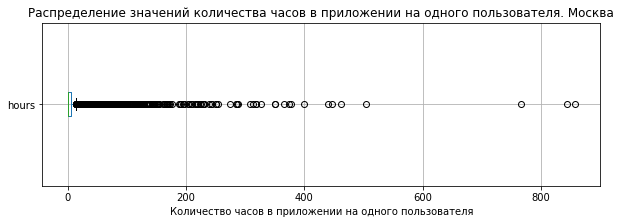

In [7]:
df_mos.boxplot(column = 'hours', figsize = (10,3), vert = False)

plt.xlabel('Количество часов в приложении на одного пользователя')
plt.title('Распределение значений количества часов в приложении на одного пользователя. Москва')
plt.show()

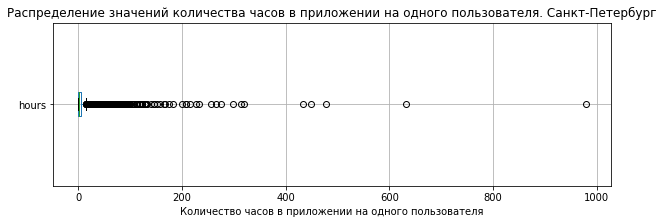

In [8]:
df_spb.boxplot(column = 'hours', figsize = (10,3), vert = False)

plt.xlabel('Количество часов в приложении на одного пользователя')
plt.title('Распределение значений количества часов в приложении на одного пользователя. Санкт-Петербург')
plt.show()

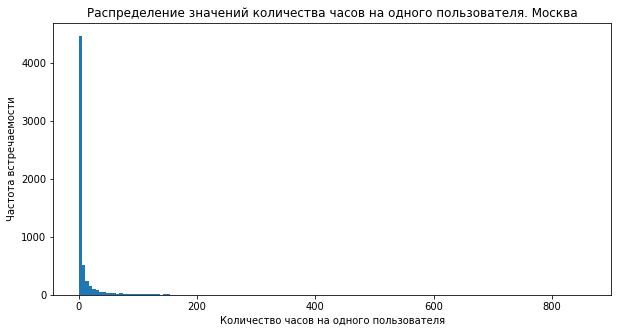

In [9]:
df_mos['hours'].plot(kind = 'hist', figsize = (10,5), bins = 150)

plt.xlabel('Количество часов на одного пользователя')
plt.ylabel('Частота встречаемости')
plt.title('Распределение значений количества часов на одного пользователя. Москва')
plt.show()

Наличие положительных выбросов делает гистограмму неинформативной, рассмотрим распределение с отсечением выбросов по 98 процентилю

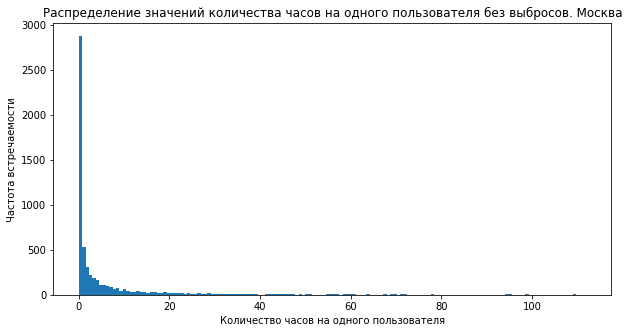

In [10]:
fliers_m = df_mos['hours'].quantile(0.98)
df_mos_nofliers = df_mos[df_mos['hours'] < fliers_m]

df_mos_nofliers['hours'].plot(kind = 'hist', figsize = (10,5), bins = 150)

plt.xlabel('Количество часов на одного пользователя')
plt.ylabel('Частота встречаемости')
plt.title('Распределение значений количества часов на одного пользователя без выбросов. Москва')
plt.show()


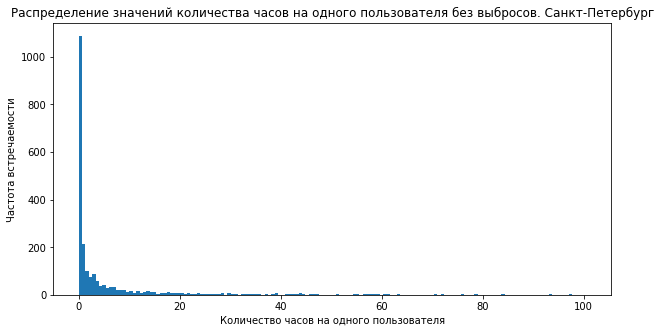

In [11]:
fliers_p = df_spb['hours'].quantile(0.98)
df_spb_nofliers = df_spb[df_spb['hours'] < fliers_p]

df_spb_nofliers['hours'].plot(kind = 'hist', figsize = (10,5), bins = 150)

plt.xlabel('Количество часов на одного пользователя')
plt.ylabel('Частота встречаемости')
plt.title('Распределение значений количества часов на одного пользователя без выбросов. Санкт-Петербург')
plt.show()


В результате анализа распределения количества часов на одного пользователя в Москве и Санкт-Петербурге можно сделать вывод о том, что оба распределения ассиметричны, имеют пик на значении близком к нулю и длинный правый хвост. Чаще всего пользователи проводят в приложении совсем немного времени: от нескольких минут до 6 часов, но есть некоторое количество пользователей, которые проводят в приложении сотни часов. Исходя из того факта, что данные у нас за период в три месяца и одиннадцать дней, пользователь из Санкт-Петербурга с максимальным количеством часов (979) проводил в приложении в среднем по 9.5 часов в день. Это маловероятно, но возможно. Для дальнейшего сравнения оставим в группах выбросы т.к. они не являются результатом технической ошибки.

Стандартное отклонение для Москвы составляет 36.9, а для Санкт-Петербурга - 39.8. Дисперсии будут расходиться значительно, поэтому для выявления значимости отличий показателя количества часов в выборках используем t-тест Уэлча.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [12]:
# H0: Среднее количество часов на пользователя в группах A(Мск) и B(СПб) не отличается, т.е. μA >= μB
# H1: (односторонняя): Среднее количество часов на пользователя в группе B(СПб) будет выше, чем в группе A(Мск), т.е. μA < μB
mos_a = df_mos['hours']
spb_b = df_spb['hours']
alpha = 0.05 

results = st.ttest_ind(mos_a, spb_b, alternative='less', equal_var = False) # берем t-тест Уэлча
p_value = results.pvalue

mos_mean = round(mos_a.mean(),2)
spb_mean = round(spb_b.mean(),2)
diff = round(spb_mean - mos_mean,1)

display(f'Среднее количество часов в приложении на одного пользователя в Москве {mos_mean}')
display(f'Среднее количество часов в приложении на одного пользователя в Санкт-Петербурге {spb_mean}, разница составляет {diff} часов')
if p_value < alpha:
    display(f'Значение p-value = {p_value}, отвергаем нулевую гипотезу')
else:
    display(f'Значение p-value = {p_value}, не получилось отвергнуть нулевую гипотезу')

'Среднее количество часов в приложении на одного пользователя в Москве 10.85'

'Среднее количество часов в приложении на одного пользователя в Санкт-Петербурге 11.26, разница составляет 0.4 часов'

'Значение p-value = 0.33179596018475044, не получилось отвергнуть нулевую гипотезу'

## 3. Аналитическая записка

Проведено сравнение двух групп пользователей на исторических данных. Вводные:
* **Группа А**: пользователи приложения в Москве, **группа В**: пользователи приложения в Санкт-Петербурге.
* Имеются занные за период с 2024-09-01 по 2024-12-11.
* Для предотвращения искажений из датасета удалено 244 пользователя, которые входили в обе группы.
* Основная метрика - количество часов в приложении на одного пользователя.
* H0: Среднее количество часов на пользователя в группах A(Мск) и B(СПб) не отличается, т.е. μA = μB
  
  H1: (односторонняя): Среднее количество часов на пользователя в группе B(СПб) будет выше, чем в группе A(Мск), т.е. μA < μB.
* Выбран стандартный уровень статистической значимости - 5%.

Так как дисперсии выборок не равны, применяем t-тест Уэлча, который не требует равенства дисперсий. 

Среднее количество часов на одного пользователя в Санкт-Петербурге больше на 0.4 часа, p-value по результатам t-теста составил 0.33, следовательно, не можем отвергнуть нулевую гипотезу о том, что средние количества часов на одного пользователя в Москве и Санкт-Петербурге равны. Такой высокий p-value говорит о том, что при условии верности нулевой гипотезы вероятность получения нашего результата составляет 33%, поэтому не можем говорить о значимых различиях в выборках.

Полученные результаты могут объясняться небольшим расхождением среднего значения и похожей формой распределения основной метрики, что в целом говорит о похожем поведении жителей Москвы и Санкт-Петербурга при использовании сервиса для чтения и прослушивания книг.


# Часть 2. Анализ результатов A/B-тестирования

Теперь нужно проанализировать другие данные. К нам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Задача — провести оценку результатов A/B-теста. Имеются:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Нужно оценить корректность проведения теста и проанализировать его результаты.

## 1. Цели исследования.



1. Оценить корректность проведенного теста и собранных данных.
2. Выбрать подходящий статистический тест и уровень статистической значимости для оценки значимости различий между конрольной и экспериментальной группами.
3. Применить статистический тест и на основе его результатов сделать вывод о наличии или отсутствии статистически значимых отличий, а значит об эффективности изменений интерфейса сайта, и о том, стоит ли экспраполировать новую версию интерфейса на всех пользователей. 

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:  </b> 
    
И снова отлично, что присутствует введение )</div>

## 2. Загрузка и предварительная оценка данных.


In [13]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

display('Участники теста:')
display(participants.head())
display('События')
display(events.head())

'Участники теста:'

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


'События'

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [14]:
display('Участники теста:')
display(participants.info())
display('События')
display(events.info())

'Участники теста:'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


None

'События'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


None

Датафрейм с участниками теста содержит 14525 строк, ни в одном столбце нет пропущенных значений.
Датафрейм с данными о событиях содержит 787286 строк, пропуски есть только в столбце `details`, это дополнительная информация, поэтому наличие пропусков допустимо.

In [15]:
dupl_participants = participants.duplicated().sum()
dupl_participants

0

In [16]:
dupl_events = participants.duplicated().sum()
dupl_events

0

Имеющиеся данные не содержат критичных пропусков и явных дубликатов. Целостность данных позволяет проводить дальнейшую обработку.


## 3. По таблице `ab_test_participants` оценим корректность проведения теста:

   3\.1 Выделим пользователей, участвующих в тесте, и проверим:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [17]:
participants['ab_test'].value_counts()

interface_eu_test          10850
recommender_system_test     3675
Name: ab_test, dtype: int64

In [18]:
participants_iet = participants[participants['ab_test'] == 'interface_eu_test']

participants_iet['group'].value_counts()

B    5467
A    5383
Name: group, dtype: int64

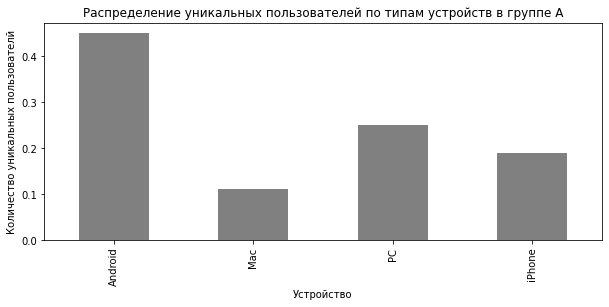

None

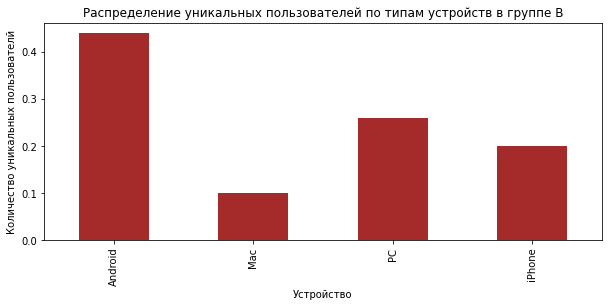

None

In [19]:
participants_a = participants_iet[participants_iet['group'] == 'A']
devices_a = participants_a.groupby('device', as_index = False)['user_id'].nunique()
devices_a['share'] = round(devices_a['user_id'] / devices_a['user_id'].sum() , 2)

a_plot = devices_a[['device','share']].set_index('device')

a_plot['share'].plot(kind = 'bar', color = 'grey', figsize = (10,4))

plt.xlabel('Устройство')
plt.ylabel('Количество уникальных пользователй')
plt.title('Распределение уникальных пользователей по типам устройств в группе А')
display(plt.show())

participants_b = participants_iet[participants_iet['group'] == 'B']
devices_b = participants_b.groupby('device', as_index = False)['user_id'].nunique()
devices_b['share'] = round(devices_b['user_id'] / devices_b['user_id'].sum() , 2)

b_plot = devices_b[['device','share']].set_index('device')

b_plot['share'].plot(kind = 'bar', color = 'brown', figsize = (10,4))

plt.xlabel('Устройство')
plt.ylabel('Количество уникальных пользователй')
plt.title('Распределение уникальных пользователей по типам устройств в группе B')
display(plt.show())


Пользователи равномерно распределены по группам теста: в группе А 5383 пользователя, в группе В 5467 пользователя. 
Доли представленности разных устройств в группах А и В сопопставимы, значит преобладание одного типа устройства не окажет влияния на результаты теста.

In [20]:
#проверим наличие пользователей, участвовавших сразу в двух тестах
by_tests = participants.groupby('user_id', as_index = False)['ab_test'].nunique()

tests_intersection = by_tests[by_tests['ab_test'] > 1]

tests_intersection

,user_id,ab_test
1,001064FEAAB631A1,2
8,00341D8401F0F665,2
23,0082295A41A867B5,2
38,00E68F103C66C1F7,2
41,00EFA157F7B6E1C4,2
...,...,...
13576,FEA0C585A53E7027,2
13582,FEC0BCA6C323872F,2
13605,FF2174A1AA0EAD20,2
13610,FF44696E39039D29,2


Есть 887 пользователей, которые стали участниками одновременно двух A/B-тестов. Это критично для анализа результатов, т.к. мы не сможем сделать выводы о том, какое воздействие из двух оказало влияние на поведение пользователей. Для анализа результатов эксперимента будем учитывать только тех пользователей, которые участвовали в одном тесте.

In [21]:
#проверим наличие пользователей, попавших сразу и в тестовую и в контрольную группы теста interface_eu_test
by_groups = participants_iet.groupby('user_id', as_index = False)['group'].nunique()

groups_intersection = by_groups[by_groups['group'] > 1]
groups_intersection

,user_id,group


Внутри теста `interface_eu_test` контрольная и тестовая группы не пересекаются, значит для получения подходящих для сравнения выборок достаточно удалить из датасета пользователей, попавших в конкурирующий A/B-тест:

In [22]:
one_test_df = by_tests[by_tests['ab_test'] == 1] #создаем датафрейм, в котором только пользователи, участвовавшие в одном тесте
one_test_users = list(one_test_df['user_id']) #создаем список id таких пользователей
only_iet_participants = participants_iet[participants_iet['user_id'].apply(lambda x: x in one_test_users)] #оставляем в списке участников нужного теста только пользователей, принявших участие в одном тесте.
only_iet_participants.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9963 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  9963 non-null   object
 1   group    9963 non-null   object
 2   ab_test  9963 non-null   object
 3   device   9963 non-null   object
dtypes: object(4)
memory usage: 389.2+ KB


In [23]:
#в полученном датафрейме не должны дублироваться id, проверим
by_rows = only_iet_participants.groupby('user_id', as_index = False)['group'].count()

by_rows_intersection = by_groups[by_groups['group'] > 1]
by_rows_intersection

,user_id,group


Получен список уникальных идентификаторов пользователей, которые приняли участие только в одном тесте и попали только в одну его группу с одним типом устройства. Обновим данные о размере групп и долях представленности устройств.

In [24]:
only_iet_participants['group'].value_counts()

B    5011
A    4952
Name: group, dtype: int64

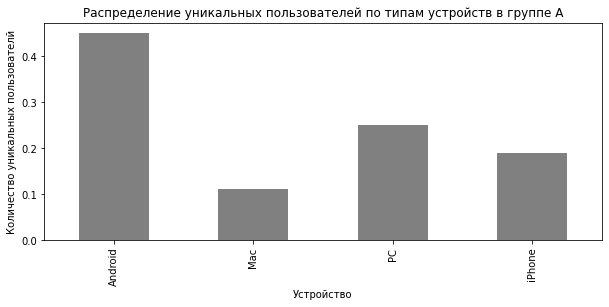

None

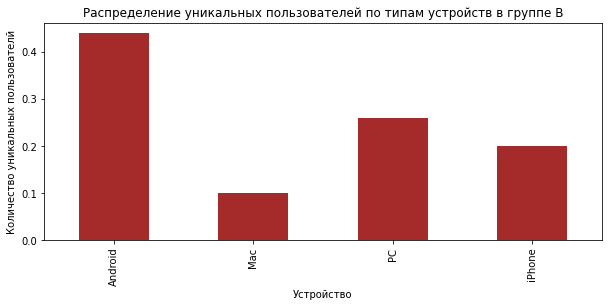

None

In [25]:
participants_iet_a = only_iet_participants[only_iet_participants['group'] == 'A']
devices_iet_a = participants_iet_a.groupby('device', as_index = False)['user_id'].nunique()
devices_iet_a['share'] = round(devices_iet_a['user_id'] / devices_iet_a['user_id'].sum() , 2)

a_iet_plot = devices_a[['device','share']].set_index('device')

a_iet_plot['share'].plot(kind = 'bar', color = 'grey', figsize = (10,4))

plt.xlabel('Устройство')
plt.ylabel('Количество уникальных пользователй')
plt.title('Распределение уникальных пользователей по типам устройств в группе А')
display(plt.show())

participants_iet_b = only_iet_participants[only_iet_participants['group'] == 'B']
devices_iet_b = participants_iet_b.groupby('device', as_index = False)['user_id'].nunique()
devices_iet_b['share'] = round(devices_iet_b['user_id'] / devices_iet_b['user_id'].sum() , 2)

b_iet_plot = devices_b[['device','share']].set_index('device')

b_iet_plot['share'].plot(kind = 'bar', color = 'brown', figsize = (10,4))

plt.xlabel('Устройство')
plt.ylabel('Количество уникальных пользователй')
plt.title('Распределение уникальных пользователей по типам устройств в группе B')
display(plt.show())

При проведении теста допущена ошибка - часть пользователей попала в два параллельно запущенных A/B-теста, данные по таким пользователям не будем принимать во внимание во избежания искажений результатов. 
После удаления 887 пользователей, участвовавших в двух тестах, получаем датафрейм с характеристиками:
* 9963 строк, четыре столбца без пропусков.
* Пользователи, участвовали только в одном тесте - `interface_eu_test`.
* Нет пересечений между группами А и В, все идентификаторы пользователей уникальны и встречаются только один раз.
* Размер группы А 4952 пользователя, размер группы В 5011 пользователей. Размеры сопоставимы, подходят для сравнения.
* Распределение пользователей в группах по устройствам одинаковы, эта переменная не повлияет на результат.

3\.2 Проанализируем данные о пользовательской активности по таблице `ab_test_events`:

- оставим только события, связанные с участвующими в изучаемом тесте пользователями;

In [26]:
only_iet_users_list = list(only_iet_participants['user_id'])
only_iet_events = events[events['user_id'].apply(lambda x: x in only_iet_users_list)]
only_iet_events.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 73815 entries, 64672 to 780371
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     73815 non-null  object        
 1   event_dt    73815 non-null  datetime64[ns]
 2   event_name  73815 non-null  object        
 3   details     19450 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 2.8+ MB


Из 787286 строк исходного датасета с событиями осталось 73815 совершенных участниками нужного A/B-теста

- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [27]:
users_reg = only_iet_events[only_iet_events['event_name'] == 'registration']

users_reg_date = users_reg[['user_id','event_dt']]

users_reg_date = users_reg_date.rename(columns = {'event_dt':'reg_dt'})

iet_events_with_reg_dt = only_iet_events.merge(users_reg_date, on = 'user_id', how = 'left')

iet_events_with_reg_dt['days_since_reg'] = (iet_events_with_reg_dt['event_dt'] - iet_events_with_reg_dt['reg_dt']) / pd.to_timedelta(1, unit='D')

iet_events_sevendays = iet_events_with_reg_dt[iet_events_with_reg_dt['days_since_reg'] <= 7]

iet_events_sevendays

,user_id,event_dt,event_name,details,reg_dt,days_since_reg
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0.000000
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0.000000
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0.000000
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0.000000
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0.000000
...,...,...,...,...,...,...
73667,E89AF4EFC757D283,2020-12-29 21:46:43,product_cart,NaN,2020-12-23 09:35:48,6.507581
73670,E89AF4EFC757D283,2020-12-29 21:47:56,product_cart,NaN,2020-12-23 09:35:48,6.508426
73739,A6AFDC94A0D3B23D,2020-12-29 22:47:00,product_page,NaN,2020-12-23 13:53:33,6.370451
73745,A6AFDC94A0D3B23D,2020-12-29 22:48:46,product_page,NaN,2020-12-23 13:53:33,6.371678


Оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

Согласно ТЗ MDE составляет три процентных пункта. 

In [28]:
# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p1 = 0.3 # Базовый уровень доли
mde = 0.03 # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p1, p1 + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

display(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

if participants_iet_a.shape[0] >= sample_size:
    display('Размер группы A больше необходимого.')
else:
    display(f'Размер группы А меньше необходимого на {sample_size - participants_iet_a.shape[0]}, результаты сравнения могут быть неточными.')

if participants_iet_b.shape[0] >= sample_size:
    display('Размер группы B больше необходимого.')
else:
    display(f'Размер группы B меньше необходимого на {sample_size - participants_iet_b.shape[0]}, результаты сравнения могут быть неточными.')
    

'Необходимый размер выборки для каждой группы: 3761'

'Размер группы A больше необходимого.'

'Размер группы B больше необходимого.'

- рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [1]:
events_users = iet_events_sevendays.merge(participants_iet, on = 'user_id', how = 'left')


visitors_a_count = events_users[events_users['group'] == 'A']['user_id'].nunique()
visitors_b_count = events_users[events_users['group'] == 'B']['user_id'].nunique()


buyers_a_count = events_users[(events_users['group'] == 'A') & (events_users['event_name'] == 'purchase')]['user_id'].nunique()
buyers_b_count = events_users[(events_users['group'] == 'B') & (events_users['event_name'] == 'purchase')]['user_id'].nunique()

cr_a = round(100 * ( buyers_a_count / visitors_a_count), 2)
cr_b = round(100 * ( buyers_b_count / visitors_b_count), 2)

display(f'В группе А всего пользователей {visitors_a_count}, из них совершили покупку {buyers_a_count}, конверсия в покупку составляет {cr_a}%')
display(f'В группе B всего пользователей {visitors_b_count}, из них совершили покупку {buyers_b_count}, конверсия в покупку составляет {cr_b}%')

NameError: name 'iet_events_sevendays' is not defined

Уровень конверсии в тестовой группе выше менее чем на 2 процентных пункта, предварительно можно сказать, что нулевая гипотеза выглядит наиболее вероятной для проведенного теста. Проверить предварительный вывод поможет z-тест пропорций.

## 4. Оценка результатов A/B-тестирования:

- Проверим изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

**Вводные A/B-теста:**
* Экспериментальное воздействие - новый интерфейс интернет-магазина.
* Основная метрика - конверсия из регистраций в покупки.
* Размер групп:
  - Контрольная группа А 4952 пользователей,
  - Экспериментальная группа В 5011 пользователей.
* Базовый уровень основной метрики 30%
* Гипотеза: упрощение интерфейса приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на три процентных пункта.

  - H0: Конверсия зарегистрированных пользователей в покупатели в течении семи дней после регистрации будет одинаковой в группе А и группе В. CR(A) = CR(B)
  - H1: Конверсия зарегистрированных пользователей в покупатели в течении семи дней после регистрации в группе В будет выше, чем в группе А. CR(A) < CR(B)

1.**Выбор статистического теста для проверки гипотезы**. Исходя из типа основной метрики - долевая, выбираем Z-тест пропорций.

2.**Уровень статистической значимости установим на 5%.**

3.**Применение статистического теста и расчёт p-value:**

In [31]:
alpha = 0.05
stat_ztest, p_value_ztest = proportions_ztest([buyers_a_count,buyers_b_count],[visitors_a_count,visitors_b_count], alternative = 'smaller')

display(f'p-value = {round(p_value_ztest,6)}')

if p_value_ztest > alpha:
    display('Не получилось отвергнуть нулевую гипотезу')
else:
    display('Отвергаем нулевую гипотезу')


'p-value = 0.028263'

'Отвергаем нулевую гипотезу'

Согласно результатам применения z-теста, можем отвергнуть нулевую гипотезу. Значит уровень конверсии для пользователей, увидевших новый вариант интерфейса интернет магазина достоверно выше. При этом необходимо учитывать, что:
1. В рамках теста уровень конверсии в экспериментальной группе всего на 1,7 провентных пункта выше, чем в контрольной группе. А MDE, заложенный для теста - 3 процентных пункта.
2. Уровень конверсии в экспериментальной группе - 29,54%, что даже ниже базового уровня конверсии - 30%, который наблюдался ретроспективно.
3. При проведении теста допущена ошибка, в результате которой пользователи попали сразу в два A/B-теста, мы не учитывали таких пользователей, но для повторных тестов рекомендую избегать таких обстоятельств.

С учетом всех этих вводных, рекомендую провести A/B-тест повторно, спланировав дизайн эксперимента более точно. В частности убедиться, что базовый уровень метрики задан корректно.